# Supervised Learning - Regression

## Importing Library Datasets

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
from ucimlrepo import fetch_ucirepo 

abalone = fetch_ucirepo(id=1) 

X = abalone.data.features 
y = abalone.data.targets 


&nbsp;

### About The Dataset

Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- a boring and time-consuming task.  Other measurements, which are easier to obtain, are used to predict the age.  Further information, such as weather patterns and location (hence food availability) may be required to solve the problem.

From the original data examples with missing values were removed (the majority having the predicted value missing), and the ranges of the continuous values have been scaled for use with an ANN (by dividing by 200).

&nbsp;

## Data Cleaning and Transformation

In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
dtypes: float64(7), str(1)
memory usage: 261.2 KB


In [4]:
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Rings   4177 non-null   int64
dtypes: int64(1)
memory usage: 32.8 KB


&nbsp;

In [5]:
# dropping non number feature
X = X.drop(columns="Sex")

In [6]:
missing_values = X.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

&nbsp;

In [7]:
# Dropping 0 value

&nbsp;

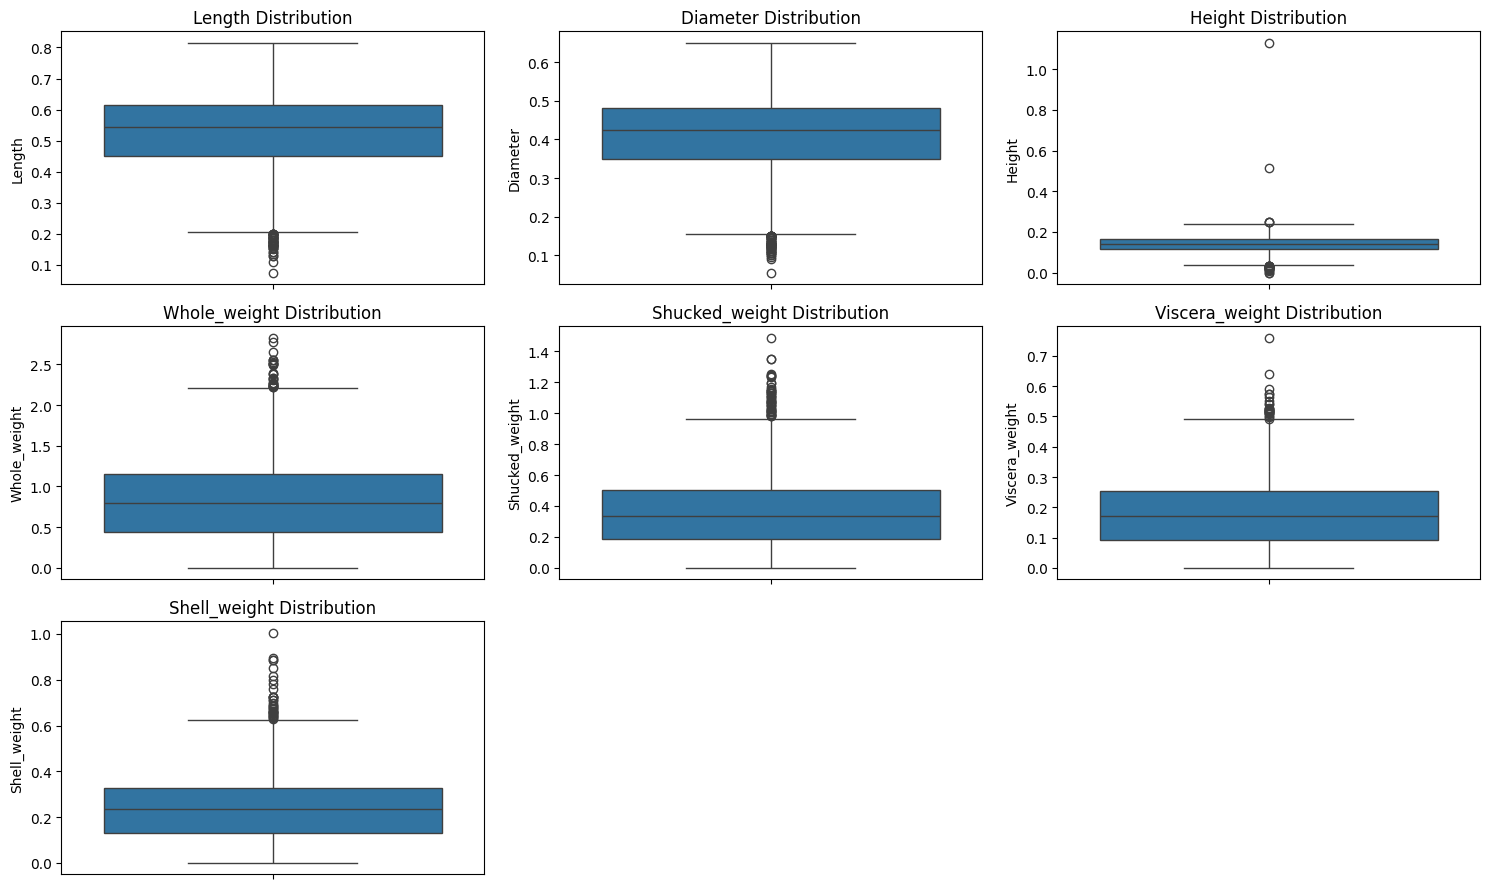

In [8]:
# Checking for outlier
n_cols = len(X.columns)
n_display_cols = 3  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(15, 3 * n_rows))

for i, column in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.boxplot(X[column])
    plt.title(f'{column} Distribution')
plt.tight_layout()
plt.show()

&nbsp;

In [9]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

condition = ~((X < (Q1 - 1 * IQR)) | (X > (Q3 + 1 * IQR))).any(axis=1)
valid_index = X.index[condition]

X = X.loc[valid_index]
y = y.loc[valid_index]

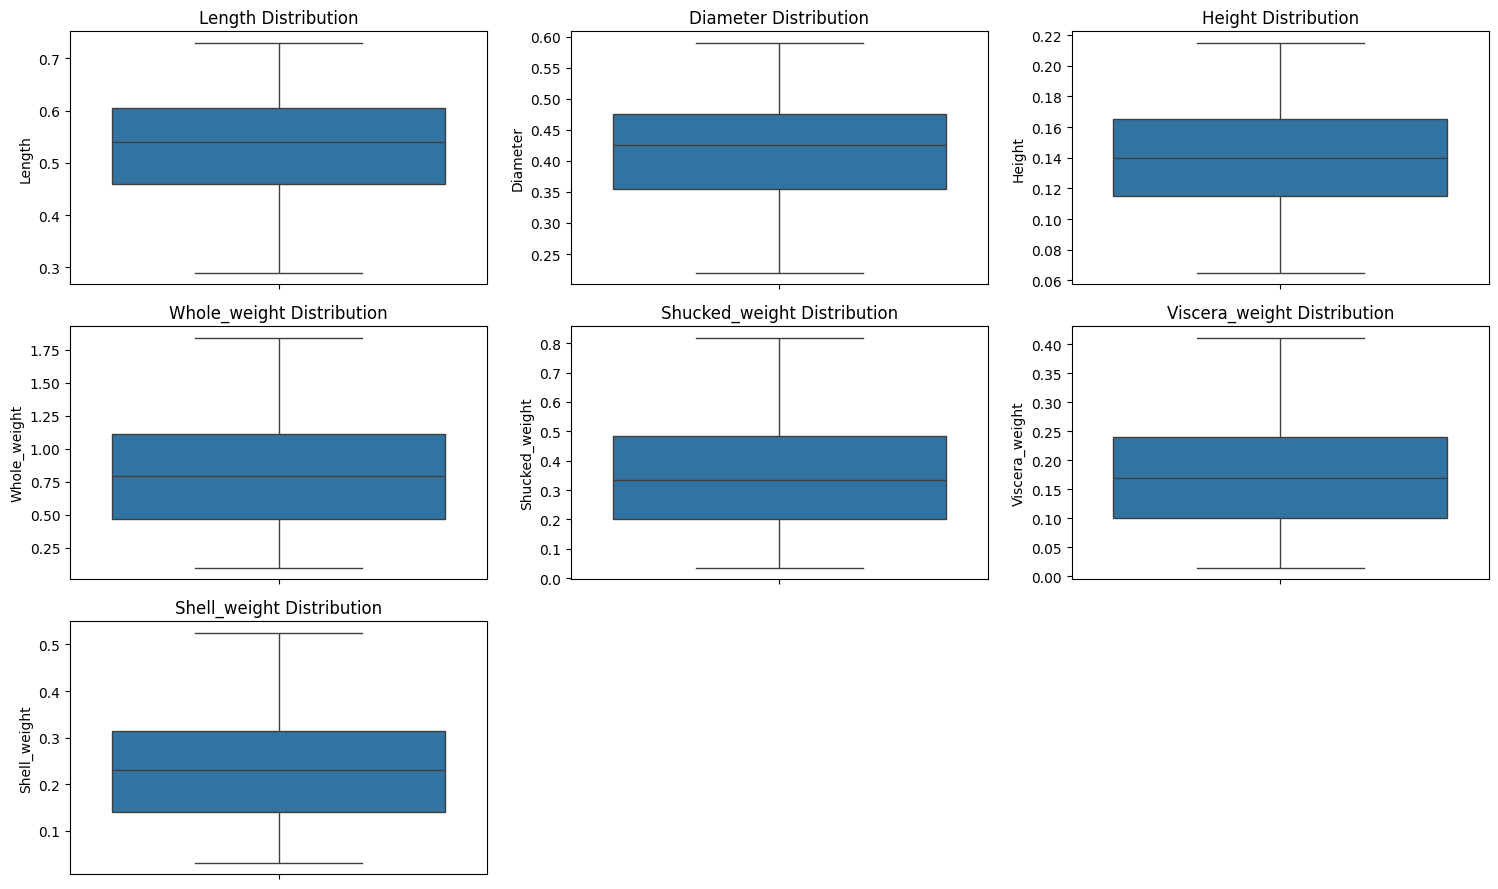

In [10]:
# Checking for outlier after cleaning
n_cols = len(X.columns)
n_display_cols = 3  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(15, 3 * n_rows))

for i, column in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.boxplot(X[column])
    plt.title(f'{column} Distribution')
plt.tight_layout()
plt.show()

&nbsp;

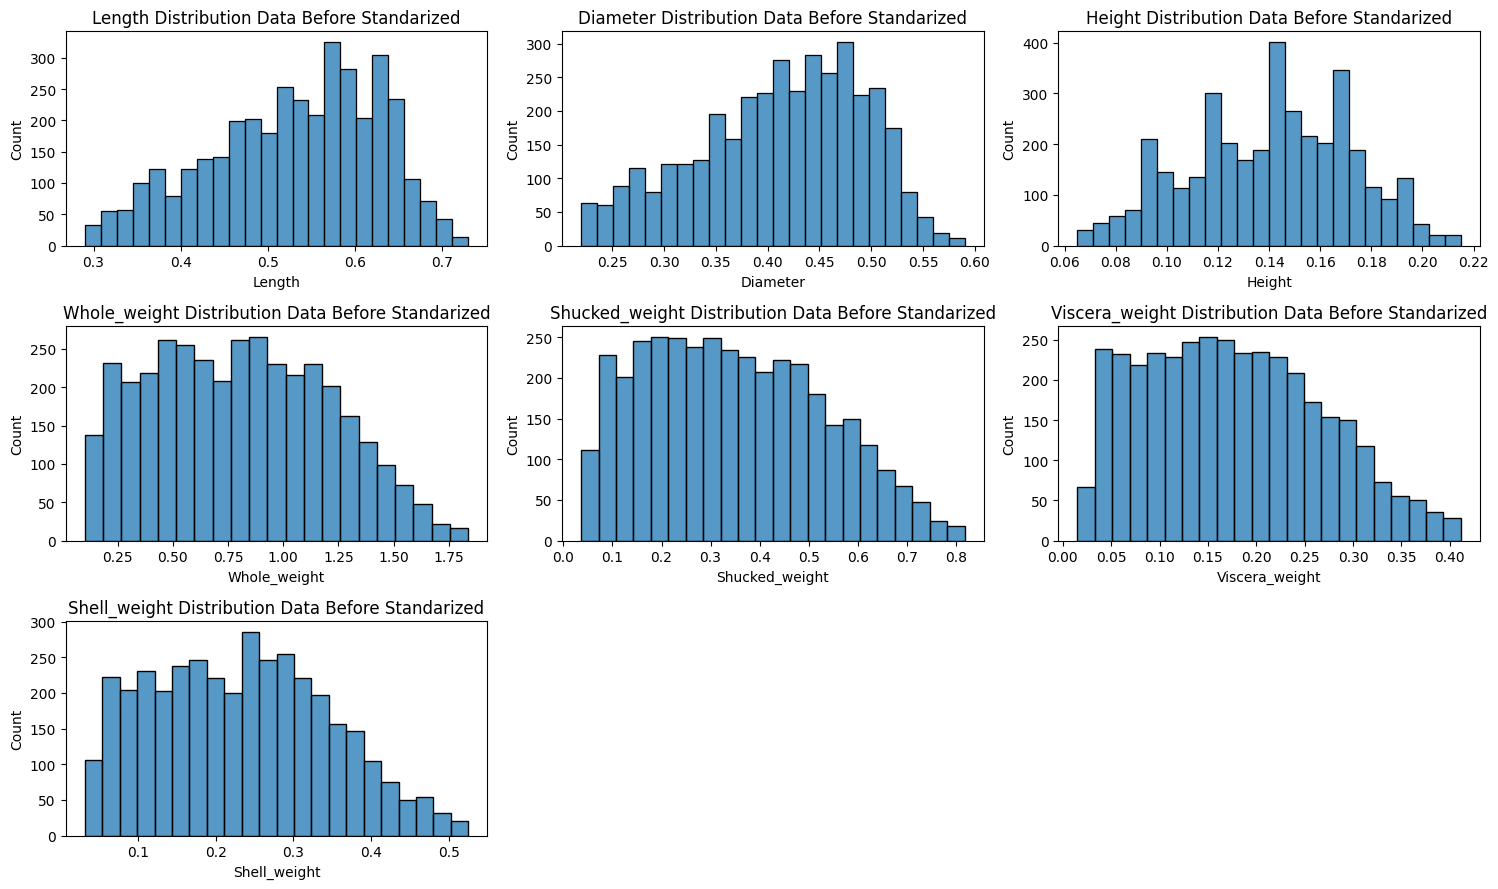

In [11]:
# standarizing the data
n_cols = len(X.columns)
n_display_cols = 3  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(15, 3 * n_rows))

for i, column in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.histplot(X[column])
    plt.title(f'{column} Distribution Data Before Standarized')
plt.tight_layout()
plt.show()

In [12]:
scaler = StandardScaler().set_output(transform="pandas")
X = scaler.fit_transform(X)

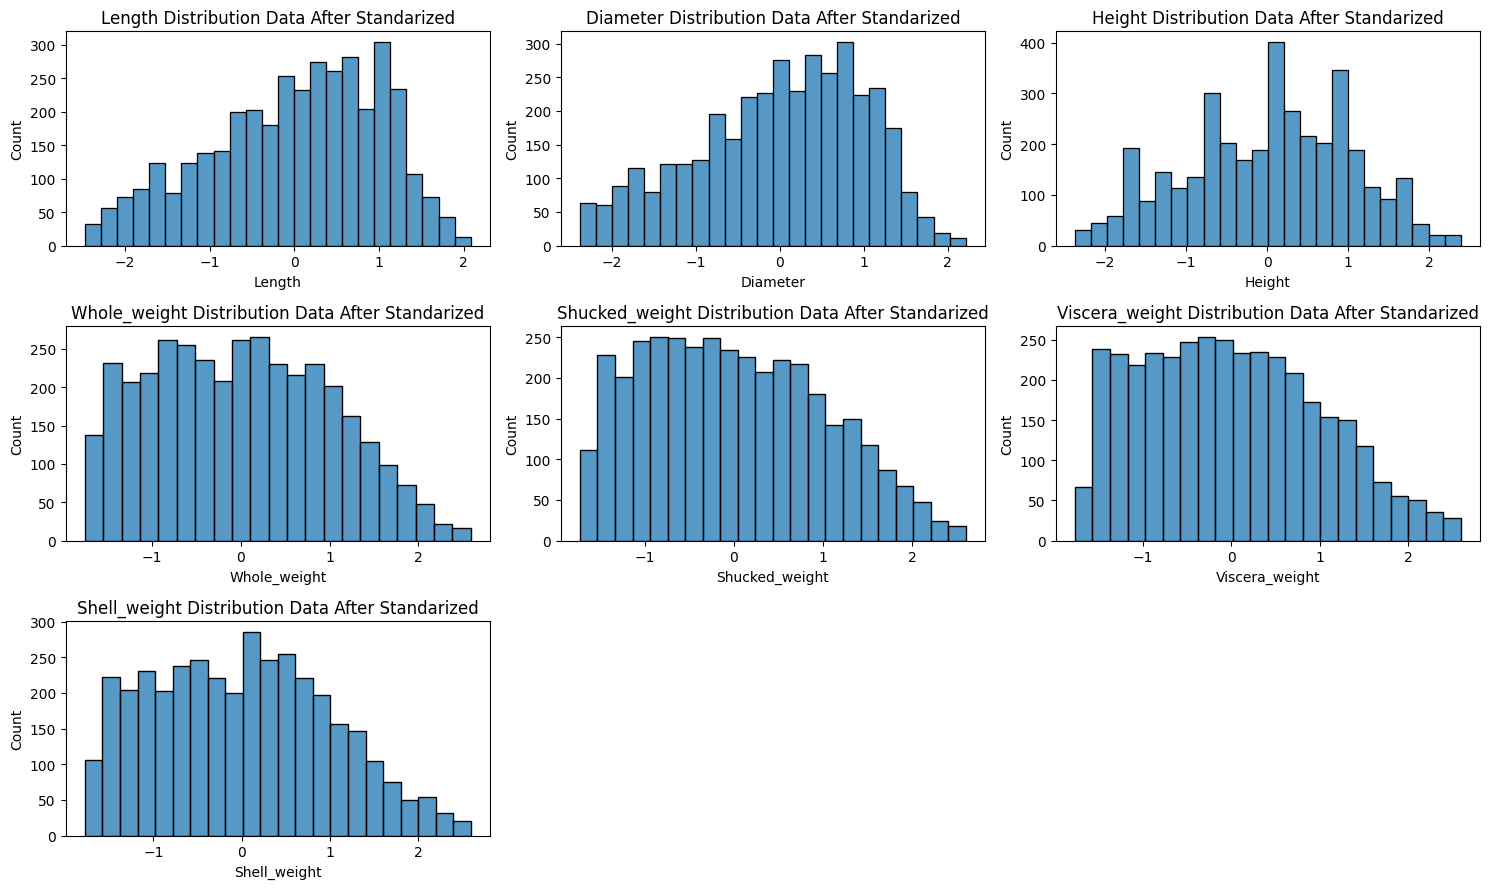

In [13]:
# Inspecting Data After Standarizing it
n_cols = len(X.columns)
n_display_cols = 3  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(15, 3 * n_rows))

for i, column in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.histplot(X[column])
    plt.title(f'{column} Distribution Data After Standarized')
plt.tight_layout()
plt.show()

&nbsp;

## EDA

In [14]:
X.describe(include='all')

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
count,3.711000e+03,3.711000e+03,3.711000e+03,3.711000e+03,3.711000e+03,3.711000e+03,3.711000e+03
mean,1.570049e-16,2.948628e-16,1.139243e-16,-1.072228e-16,5.169672e-16,-4.020856e-17,-3.829387e-18
std,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00,1.000135e+00
min,-2.471504e+00,-2.381181e+00,-2.373366e+00,-1.757667e+00,-1.727858e+00,-1.763657e+00,-1.775383e+00
25%,-7.123326e-01,-7.046967e-01,-7.867326e-01,-8.306500e-01,-8.195541e-01,-8.153872e-01,-8.151667e-01
50%,1.155130e-01,1.645915e-01,6.584252e-03,-2.123018e-02,-7.740378e-02,-7.051429e-02,-1.867402e-02
75%,7.881375e-01,7.855117e-01,7.999011e-01,7.750538e-01,7.505923e-01,7.210850e-01,7.335690e-01
max,2.081646e+00,2.213628e+00,2.386535e+00,2.589681e+00,2.603199e+00,2.595636e+00,2.592052e+00


as we can see the data is pretty much good enough and actually really in a good format

&nbsp;

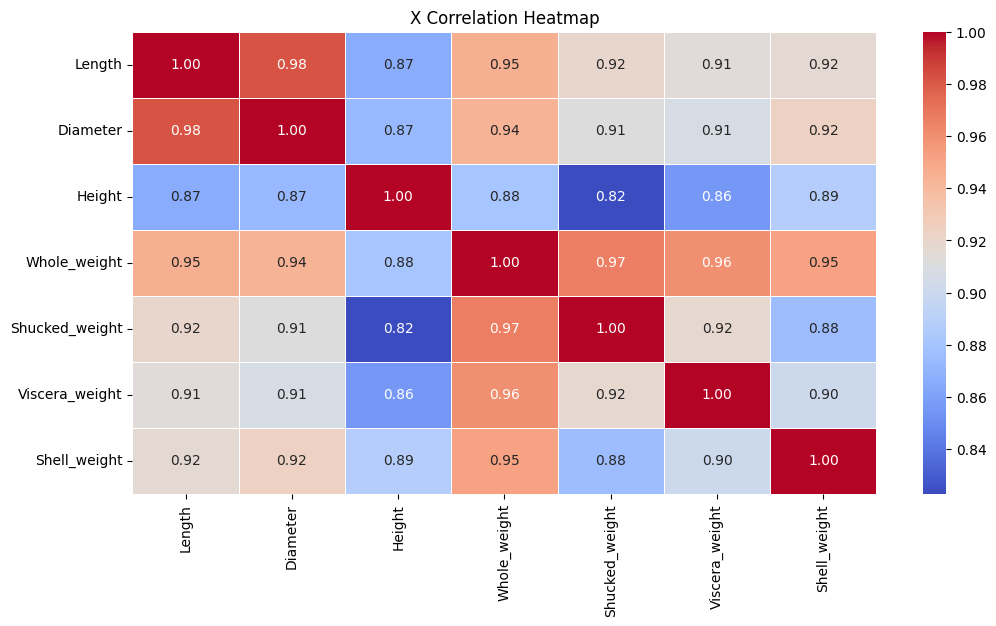

In [15]:
# Displaying Correlation Between Numerical Features Using Heatmap
plt.figure(figsize=(12,6))
corr_mat = X.corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("X Correlation Heatmap")
plt.show()

&nbsp;

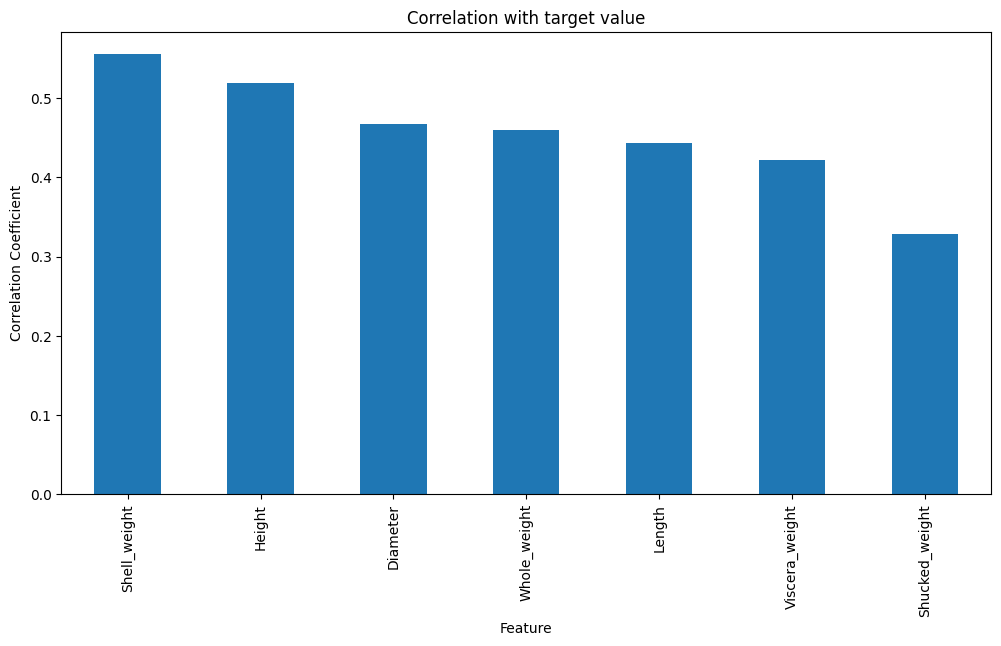

In [16]:
target_corr = X.corrwith(y['Rings'])

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
target_corr_sorted.plot(kind='bar')
plt.title('Correlation with target value')
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.show()

&nbsp;

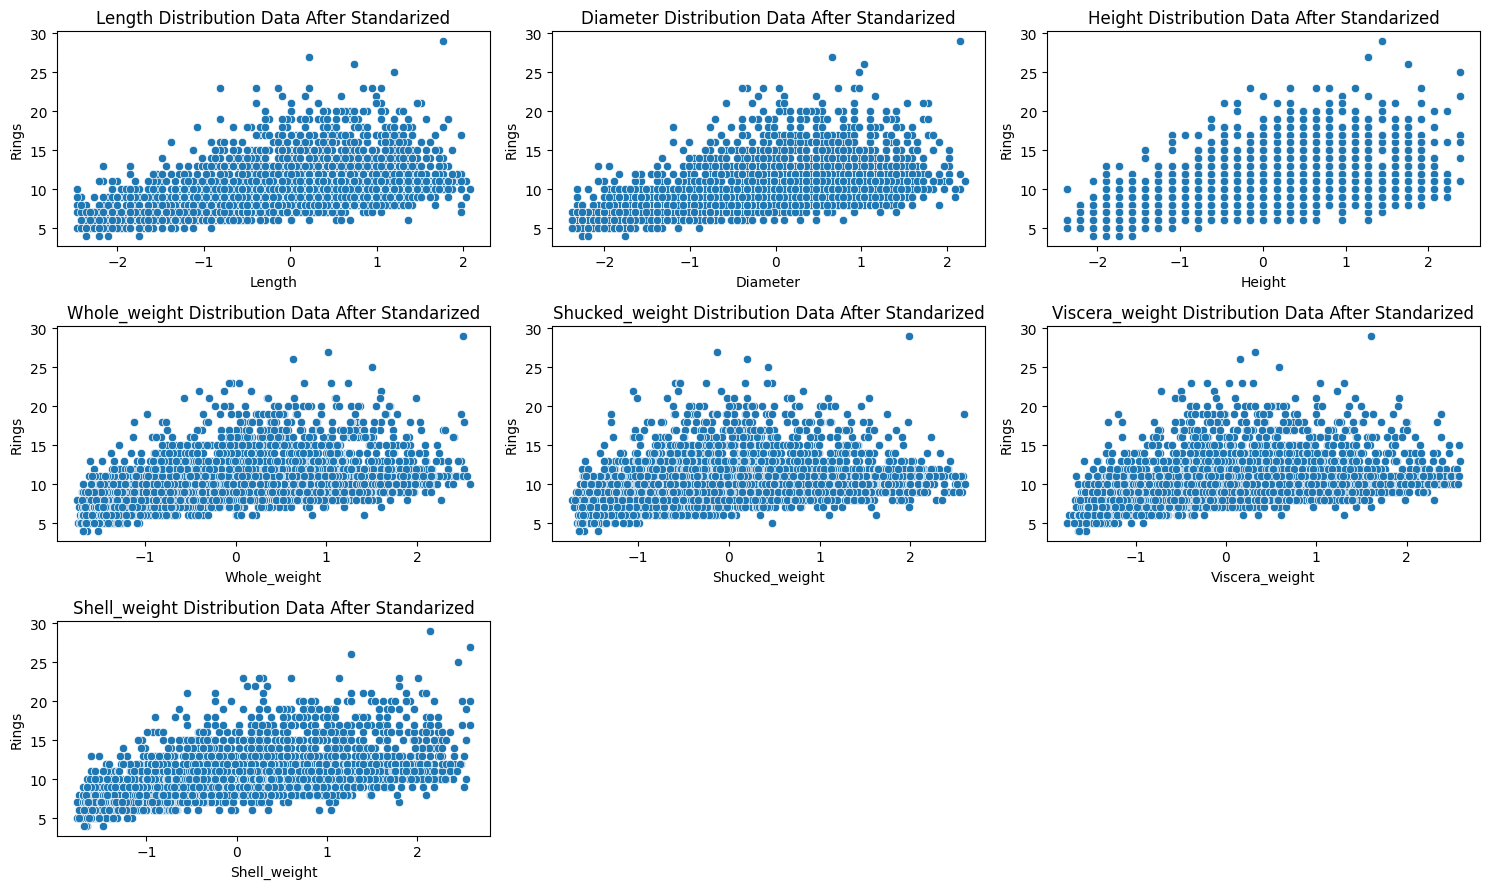

In [30]:
# Seeing the ppatern in the fetaure
n_cols = len(X.columns)
n_display_cols = 3  # How many plots per row
n_rows = math.ceil(n_cols / n_display_cols)

plt.figure(figsize=(15, 3 * n_rows))

for i, column in enumerate(X.columns, 1):
    plt.subplot(n_rows, n_display_cols, i)
    sns.scatterplot(x=X[column], y=y['Rings'])
    plt.title(f'{column} Distribution Data After Standarized')
plt.tight_layout()
plt.show()

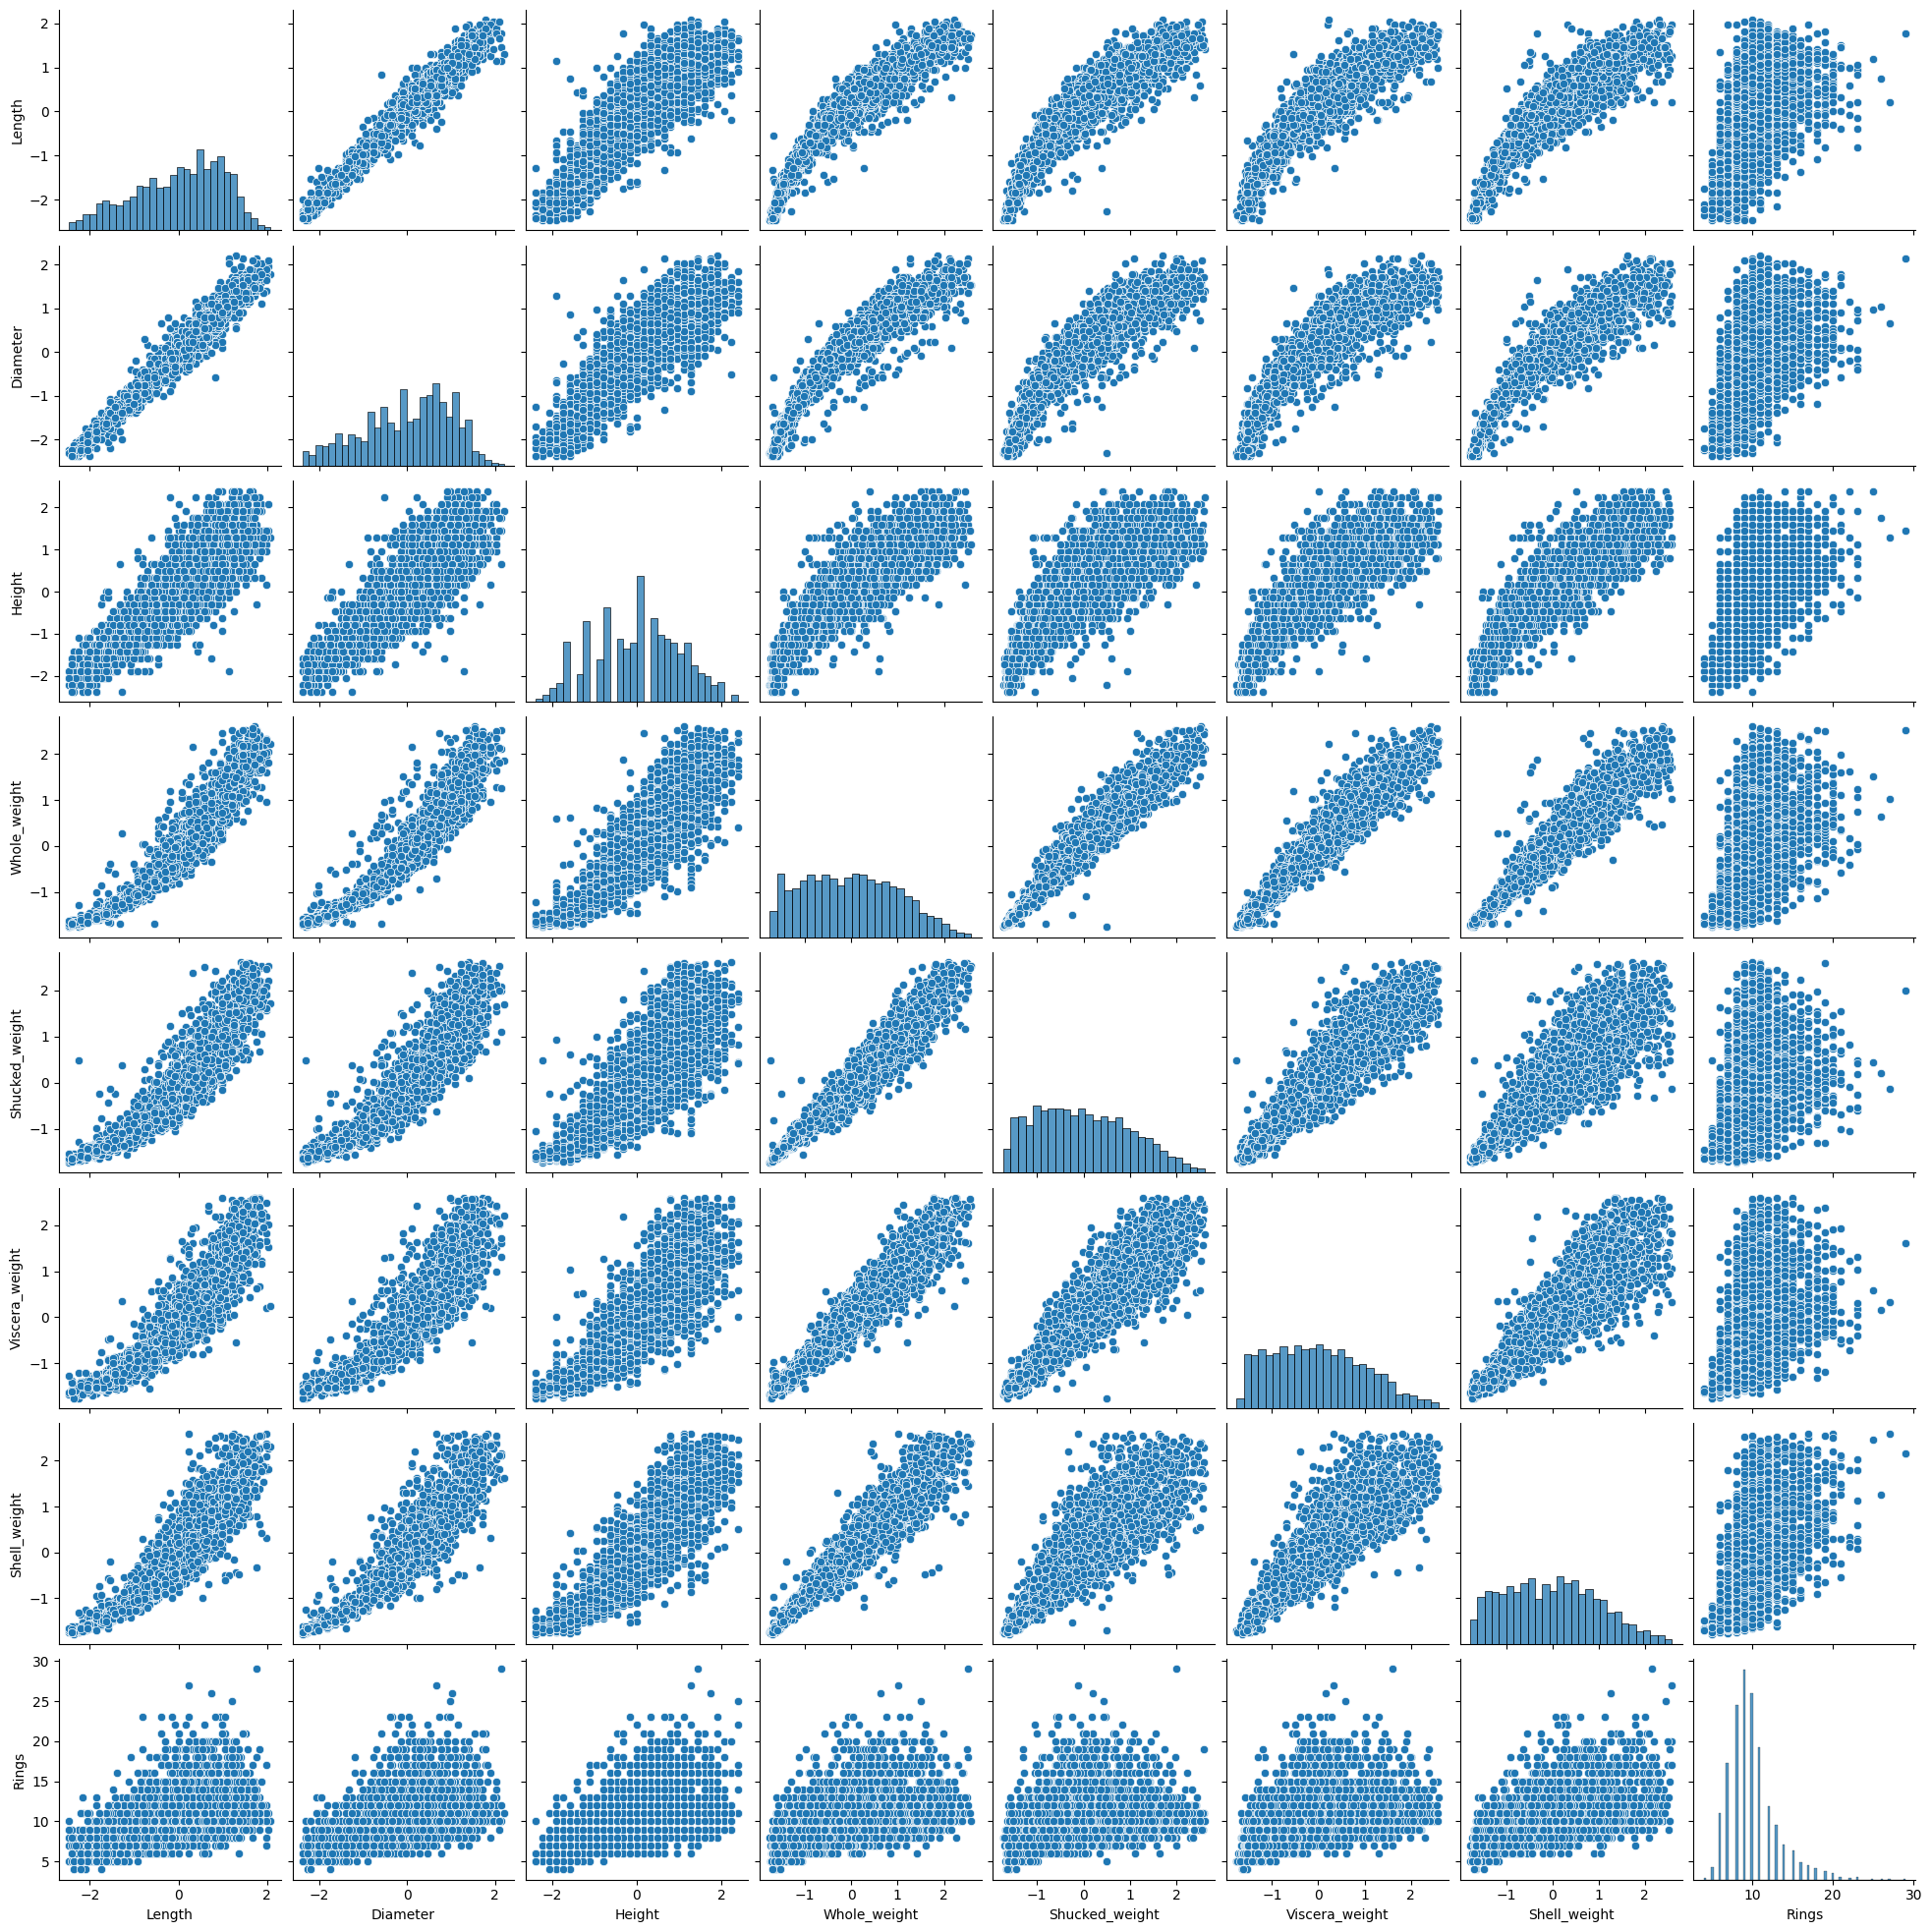

In [38]:
sns.pairplot(pd.concat([X, y]))

&nbsp;

## Data Splitting

In [18]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Total data: ", len(X))
print("Total train data : ", len(x_train))
print("Total test data : ", len(x_test))

Total data:  3711
Total train data :  2968
Total test data :  743


&nbsp;

## Model Training

### Lars

In [19]:

lars = linear_model.Lars(n_nonzero_coefs=1).fit(x_train, y_train)
pred_lars = lars.predict(x_test)

&nbsp;

### Linear Regression

In [20]:
LR = LinearRegression().fit(x_train, y_train)
pred_LR = LR.predict(x_test)

&nbsp;

### GradientBoostingRegressor

In [21]:
GBR = GradientBoostingRegressor(random_state=184)
GBR.fit(x_train, y_train.values.ravel())
pred_GBR = GBR.predict(x_test)

&nbsp;

## Model Testing

### Lars

In [22]:
mae_lars = mean_absolute_error(y_test, pred_lars)
mse_lars = mean_squared_error(y_test, pred_lars)
r2_lars = r2_score(y_test, pred_lars)

print(f"MAE: {mae_lars}")
print(f"MSE: {mse_lars}")
print(f"R²: {r2_lars}")

data = {
    'MAE': [mae_lars],
    'MSE': [mse_lars],
    'R2': [r2_lars]
}

# Konversi dictionary menjadi DataFrame
df_results = pd.DataFrame(data, index=['Lars'])
df_results

MAE: 1.87920729767334
MSE: 6.782656695263434
R²: 0.26535852993897346


,MAE,MSE,R2
Lars,1.879207,6.782657,0.265359


&nbsp;

### Linear Regression

In [23]:
mae_LR = mean_absolute_error(y_test, pred_LR)
mse_LR = mean_squared_error(y_test, pred_LR)
r2_LR = r2_score(y_test, pred_LR)


mae_LR = mean_absolute_error(y_test, pred_LR)
mse_LR = mean_squared_error(y_test, pred_LR)
r2_LR = r2_score(y_test, pred_LR)


data_LR = {
    'MAE': [mae_LR],
    'MSE': [mse_LR],
    'R2': [r2_LR]
}

# Konversi dictionary menjadi DataFrame
df_results_LR = pd.DataFrame(data_LR, index=['Lars'])
df_results_LR

,MAE,MSE,R2
Lars,1.595282,4.826385,0.477246


&nbsp;

### GradientBoostingRegressor

In [24]:
mae_GBR = mean_absolute_error(y_test, pred_GBR)
mse_GBR = mean_squared_error(y_test, pred_GBR)
r2_GBR = r2_score(y_test, pred_GBR)

data_GBR = {
    'MAE': [mae_GBR],
    'MSE': [mse_GBR],
    'R2': [r2_GBR]
}

# Konversi dictionary menjadi DataFrame
df_results_GBR = pd.DataFrame(data_GBR, index=['Lars'])
df_results_GBR

,MAE,MSE,R2
Lars,1.546559,4.843494,0.475393


the results is too bad shown by the $R2$ that didnt reach 0.5 even with using GBR, one approach to fix this is by using feature engineering

&nbsp;

## Feature Engineering

In [25]:
# feature Engineering for X value
X_eng = X.copy()

X_eng['Volume'] = X_eng['Length'] * X_eng['Diameter'] * X_eng['Height']

X_eng['Density'] = X_eng['Whole_weight'] / (X_eng['Volume'] + 1e-6)

# Calculate Shell Ratio: Older abalones tend to have heavier shells relative to meat
X_eng['Shell_Ratio'] = X_eng['Shell_weight'] / (X_eng['Whole_weight'] + 1e-6)

&nbsp;

In [26]:
# feature Engineering for y value
y_eng = y.copy()

&nbsp;

In [27]:
# re attempting training the model
scaler = StandardScaler().set_output(transform="pandas")
X_eng = scaler.fit_transform(X_eng)

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(X_eng, y_eng.values.ravel(), test_size=0.2, random_state=42)

model_gbr_eng = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gbr_eng.fit(X_train_eng, y_train_eng)
pred_gbr_eng = model_gbr_eng.predict(X_test_eng)

# 4. Results
results_gbr_eng = {
    'MAE_GBR_ENG': mean_absolute_error(y_test_eng, pred_gbr_eng),
    'MSE_GBR_ENG': mean_squared_error(y_test_eng, pred_gbr_eng),
    'R2_GBR_ENG': r2_score(y_test_eng, pred_gbr_eng)
}

print("New Gradient Boosting Results with Feature Engineering:")
print(pd.DataFrame([results_gbr_eng], index=['GBR_Enhanced']))

New Gradient Boosting Results with Feature Engineering:
              MAE_GBR_ENG  MSE_GBR_ENG  R2_GBR_ENG
GBR_Enhanced     1.599421     4.812543    0.417695


nvm it getting worse wth